#### **Vehicle Classification: Random Forest — Raw Features vs PCA**

**Dataset:** Vehicle silhouette features (18 numeric features)  
**Classes:** `bus`, `van`, `car`, `saab`  
**Goal:** Train a Random Forest classifier on the raw features, then on PCA-reduced features, and compare performance.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
print('Libraries loaded ✓')

Libraries loaded ✓


#### **Load & Explore Data**

In [2]:
df = pd.read_csv("./data/vehicle-2.csv")
print(f'Shape: {df.shape}')
print(f'\nClass distribution:')
print(df['class'].value_counts())
df.head()

Shape: (846, 19)

Class distribution:
class
car    429
bus    218
van    199
Name: count, dtype: int64


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [3]:
# filling mising values

X = df.iloc[:,0:18] #separating all numercial independent attribute
y = df.iloc[:,18] #seprarting class attribute.
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X_imputed = imputer.fit_transform(X)
X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns)
df = pd.concat([X_imputed_df, y.reset_index(drop=True)], axis=1)

print(f"Are there any NaNs? {'Yes' if df.isnull().values.any() else 'No'}")

Are there any NaNs? No


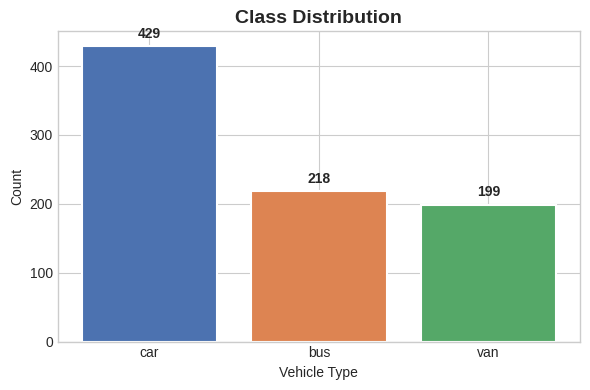

In [4]:
# Class balance
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['class'].value_counts()
bars = ax.bar(counts.index, counts.values, color=PALETTE, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, padding=4, fontweight='bold')
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Vehicle Type'); ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

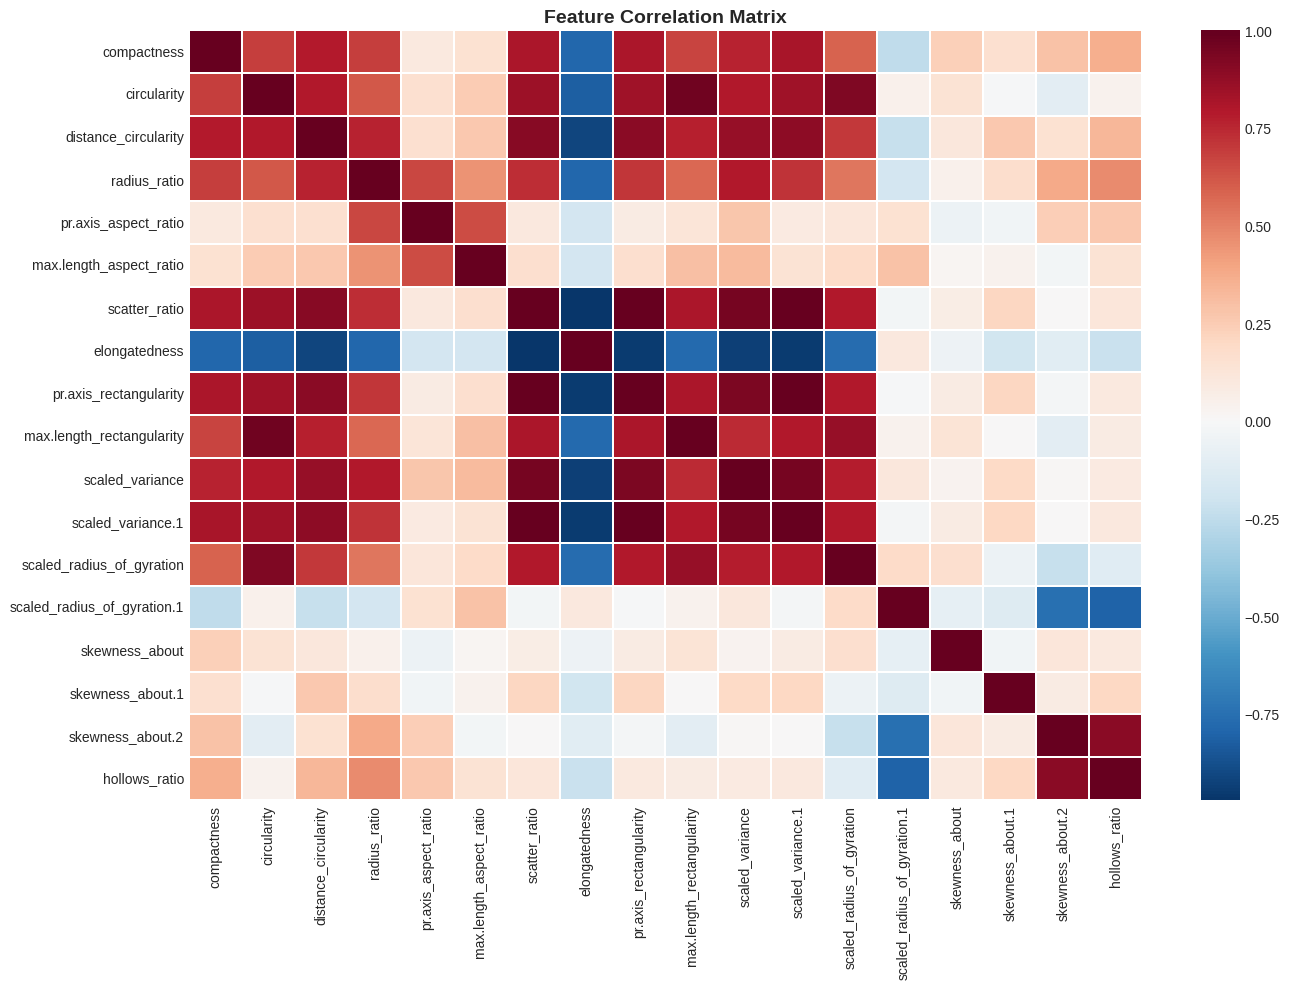

In [5]:
# Feature correlation heatmap
feature_cols = [c for c in df.columns if c != 'class']
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(df[feature_cols].corr(), cmap='RdBu_r', center=0,
            annot=False, linewidths=0.3, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### **Data Preprocessing**

In [6]:
# Encode labels
le = LabelEncoder()
y = le.fit_transform(df['class'])
X = df[feature_cols].values

print(f'Features shape: {X.shape}')
print(f'Classes: {le.classes_}')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train size: {X_train_scaled.shape[0]} | Test size: {X_test_scaled.shape[0]}')

Features shape: (846, 18)
Classes: ['bus' 'car' 'van']
Train size: 634 | Test size: 212


#### **Model A — Random Forest on Raw Features (18 dimensions)**

In [7]:
rf_raw = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_raw.fit(X_train_scaled, y_train)

y_pred_raw = rf_raw.predict(X_test_scaled)
acc_raw = accuracy_score(y_test, y_pred_raw)

cv_raw = cross_val_score(rf_raw, X_train_scaled, y_train, cv=5, scoring='accuracy')

print(f'=== Random Forest — Raw Features (18 dims) ===')
print(f'Test Accuracy : {acc_raw:.4f} ({acc_raw*100:.2f}%)')
print(f'CV Accuracy   : {cv_raw.mean():.4f} ± {cv_raw.std():.4f}')
print()
print(classification_report(y_test, y_pred_raw, target_names=le.classes_))

=== Random Forest — Raw Features (18 dims) ===
Test Accuracy : 0.9717 (97.17%)
CV Accuracy   : 0.9511 ± 0.0169

              precision    recall  f1-score   support

         bus       0.96      0.98      0.97        55
         car       0.98      0.96      0.97       107
         van       0.96      0.98      0.97        50

    accuracy                           0.97       212
   macro avg       0.97      0.97      0.97       212
weighted avg       0.97      0.97      0.97       212



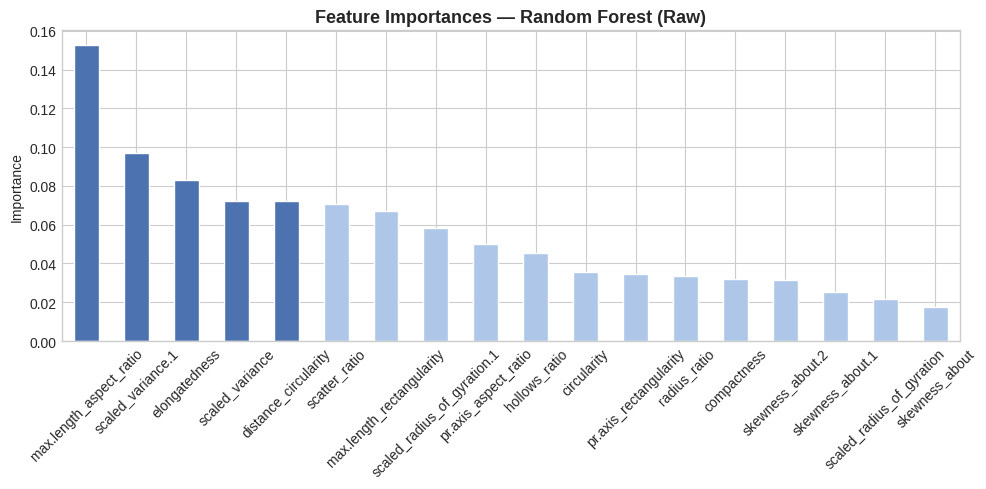

In [8]:
# Feature importances
importances = pd.Series(rf_raw.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4C72B0' if i < 5 else '#AEC6E8' for i in range(len(importances))]
importances.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importances — Random Forest (Raw)', fontsize=13, fontweight='bold')
ax.set_ylabel('Importance'); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

#### **Model on a PCA Transformation**

In [9]:
# Fit PCA on training data
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Find number of components for 95% variance
n_components_95 = np.argmax(cumulative >= 0.95) + 1
print(f'Components to explain 95% variance: {n_components_95}')
print(f'\nVariance explained per component:')
for i, (e, c) in enumerate(zip(explained[:10], cumulative[:10]), 1):
    print(f'  PC{i:02d}: {e:.4f} ({e*100:.2f}%) | Cumulative: {c*100:.2f}%')

Components to explain 95% variance: 7

Variance explained per component:
  PC01: 0.5204 (52.04%) | Cumulative: 52.04%
  PC02: 0.1688 (16.88%) | Cumulative: 68.92%
  PC03: 0.1083 (10.83%) | Cumulative: 79.76%
  PC04: 0.0632 (6.32%) | Cumulative: 86.08%
  PC05: 0.0523 (5.23%) | Cumulative: 91.31%
  PC06: 0.0296 (2.96%) | Cumulative: 94.26%
  PC07: 0.0197 (1.97%) | Cumulative: 96.24%
  PC08: 0.0115 (1.15%) | Cumulative: 97.39%
  PC09: 0.0091 (0.91%) | Cumulative: 98.29%
  PC10: 0.0053 (0.53%) | Cumulative: 98.82%


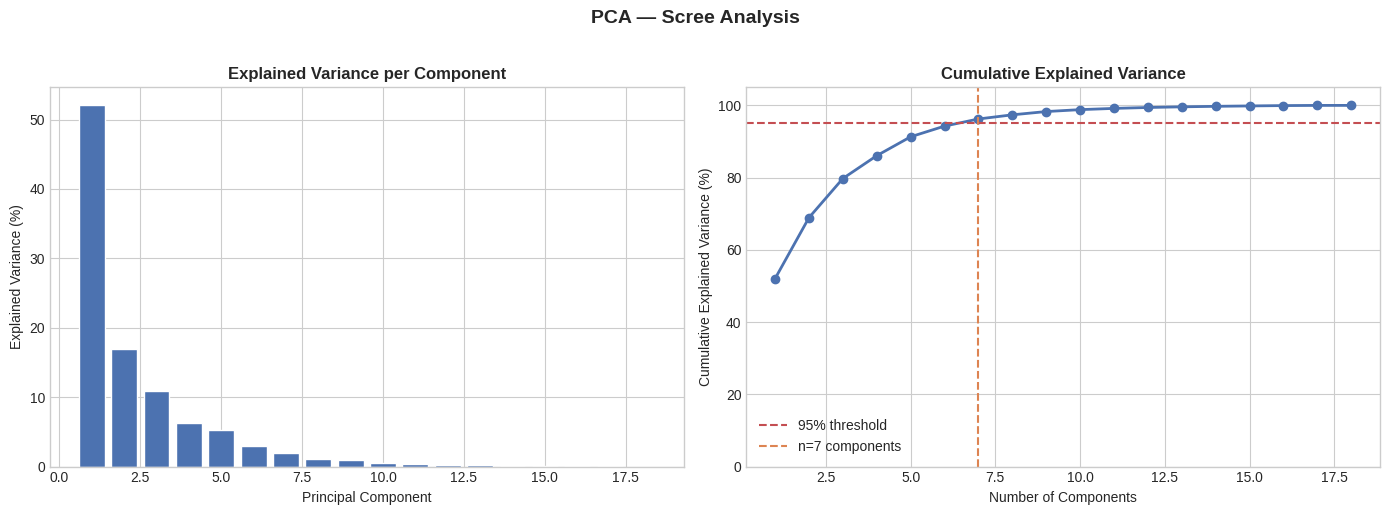

In [10]:
# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance
axes[0].bar(range(1, len(explained)+1), explained*100, color='#4C72B0', edgecolor='white')
axes[0].set_title('Explained Variance per Component', fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')

# Cumulative
axes[1].plot(range(1, len(cumulative)+1), cumulative*100, 'o-', color='#4C72B0', linewidth=2)
axes[1].axhline(y=95, color='#C44E52', linestyle='--', linewidth=1.5, label='95% threshold')
axes[1].axvline(x=n_components_95, color='#DD8452', linestyle='--', linewidth=1.5,
                label=f'n={n_components_95} components')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].legend()
axes[1].set_ylim(0, 105)

plt.suptitle('PCA — Scree Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Apply PCA with n_components_95 components
n_components = n_components_95

print('We apply a dimensionality reduction to n_components',n_components)

pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f'Original shape : {X_train_scaled.shape}')
print(f'PCA shape      : {X_train_pca.shape}')
print(f'Dimensionality reduction: {X_train_scaled.shape[1]} → {X_train_pca.shape[1]} features')

We apply a dimensionality reduction to n_components 10
Original shape : (634, 18)
PCA shape      : (634, 10)
Dimensionality reduction: 18 → 10 features


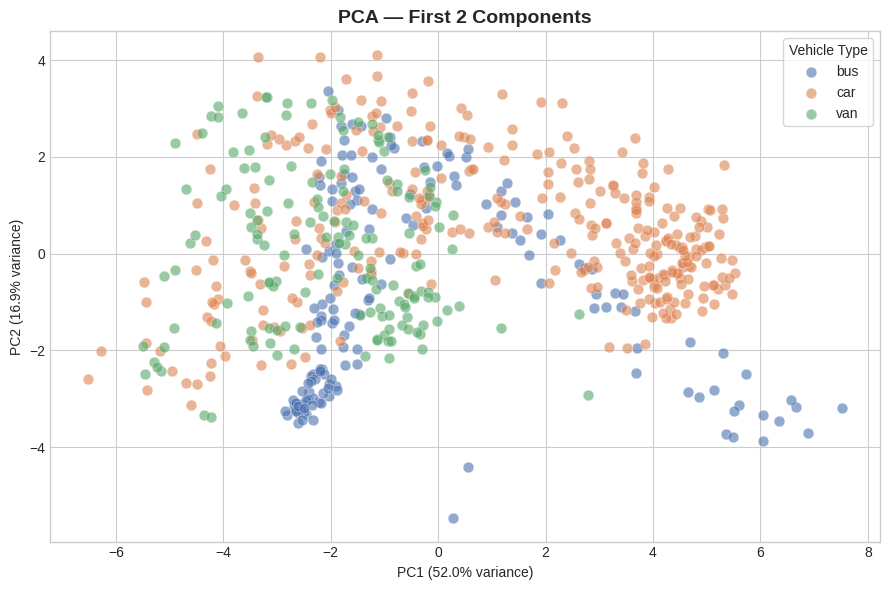

In [12]:
# Visualize first 2 PCA components
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X_train_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
for i, cls in enumerate(le.classes_):
    mask = y_train == i
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1], label=cls,
               color=PALETTE[i], alpha=0.6, s=60, edgecolors='white', linewidths=0.4)

ax.set_title('PCA — First 2 Components', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(title='Vehicle Type', frameon=True)
plt.tight_layout()
plt.show()

#### **Model B — Random Forest on PCA Features**

In [13]:
rf_pca = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_pca.fit(X_train_pca, y_train)

y_pred_pca = rf_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

cv_pca = cross_val_score(rf_pca, X_train_pca, y_train, cv=5, scoring='accuracy')

print(f'=== Random Forest — PCA Features ({n_components} dims) ===')
print(f'Test Accuracy : {acc_pca:.4f} ({acc_pca*100:.2f}%)')
print(f'CV Accuracy   : {cv_pca.mean():.4f} ± {cv_pca.std():.4f}')
print()
print(classification_report(y_test, y_pred_pca, target_names=le.classes_))

=== Random Forest — PCA Features (10 dims) ===
Test Accuracy : 0.9434 (94.34%)
CV Accuracy   : 0.9338 ± 0.0080

              precision    recall  f1-score   support

         bus       0.93      0.96      0.95        55
         car       0.94      0.96      0.95       107
         van       0.96      0.88      0.92        50

    accuracy                           0.94       212
   macro avg       0.94      0.94      0.94       212
weighted avg       0.94      0.94      0.94       212



#### **Results Comparison**

In [14]:
# ── Summary table ──
results = pd.DataFrame({
    'Model': ['RF — Raw (18 features)', f'RF — PCA ({n_components} components)'],
    'Features': [18, n_components],
    'Test Accuracy': [acc_raw, acc_pca],
    'CV Mean': [cv_raw.mean(), cv_pca.mean()],
    'CV Std': [cv_raw.std(), cv_pca.std()],
    'Dim. Reduction': ['—', f'{18} → {n_components} ({(1 - n_components/18)*100:.0f}% reduction)']
})

results['Test Accuracy'] = results['Test Accuracy'].map('{:.4f}'.format)
results['CV Mean']       = results['CV Mean'].map('{:.4f}'.format)
results['CV Std']        = results['CV Std'].map('{:.4f}'.format)

print('='*70)
print('COMPARISON SUMMARY')
print('='*70)
print(results.to_string(index=False))
print('='*70)

COMPARISON SUMMARY
                   Model  Features Test Accuracy CV Mean CV Std          Dim. Reduction
  RF — Raw (18 features)        18        0.9717  0.9511 0.0169                       —
RF — PCA (10 components)        10        0.9434  0.9338 0.0080 18 → 10 (44% reduction)


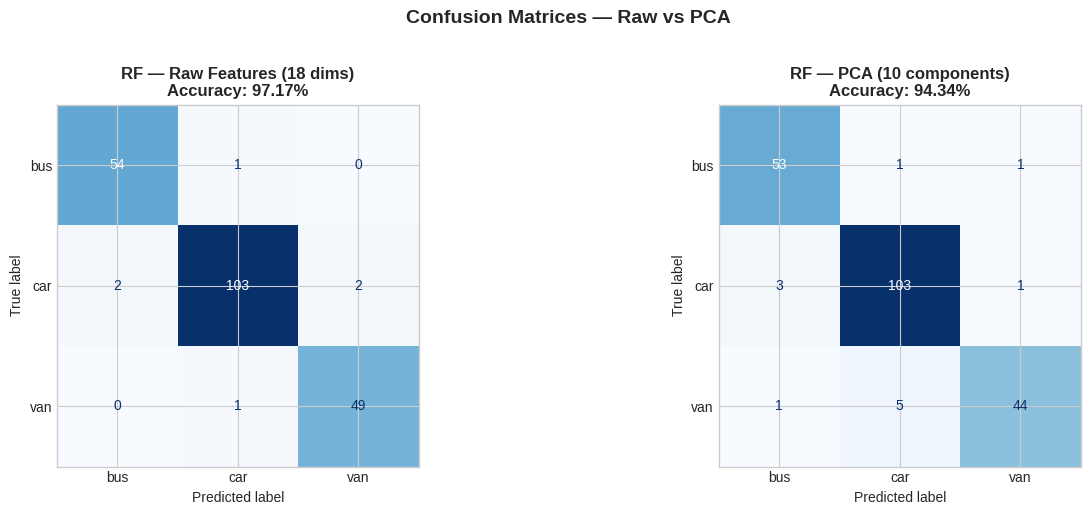

In [15]:
# ── Confusion matrices side-by-side ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_raw, y_pred_pca],
    [f'RF — Raw Features (18 dims)\nAccuracy: {acc_raw*100:.2f}%',
     f'RF — PCA ({n_components} components)\nAccuracy: {acc_pca*100:.2f}%']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — Raw vs PCA', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

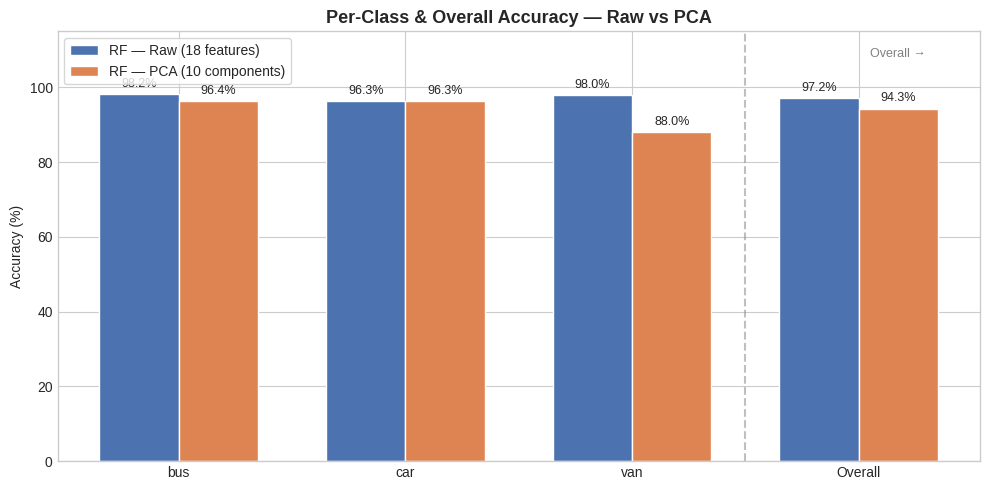

In [16]:
# ── Bar chart comparison ──
classes = list(le.classes_) + ['Overall']

def per_class_accuracy(y_true, y_pred, n_classes):
    accs = []
    for c in range(n_classes):
        mask = y_true == c
        accs.append(accuracy_score(y_true[mask], y_pred[mask]))
    accs.append(accuracy_score(y_true, y_pred))
    return accs

acc_raw_per = per_class_accuracy(y_test, y_pred_raw, len(le.classes_))
acc_pca_per = per_class_accuracy(y_test, y_pred_pca, len(le.classes_))

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, [v*100 for v in acc_raw_per], width,
            label='RF — Raw (18 features)', color='#4C72B0', edgecolor='white')
b2 = ax.bar(x + width/2, [v*100 for v in acc_pca_per], width,
            label=f'RF — PCA ({n_components} components)', color='#DD8452', edgecolor='white')

ax.bar_label(b1, fmt='%.1f%%', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.1f%%', padding=3, fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylim(0, 115)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class & Overall Accuracy — Raw vs PCA', fontsize=13, fontweight='bold')
ax.legend(frameon=True)
ax.axvline(x=len(le.classes_)-0.5, color='gray', linestyle='--', alpha=0.5)
ax.text(len(le.classes_)+0.05, 108, 'Overall →', fontsize=9, color='gray')
plt.tight_layout()
plt.show()

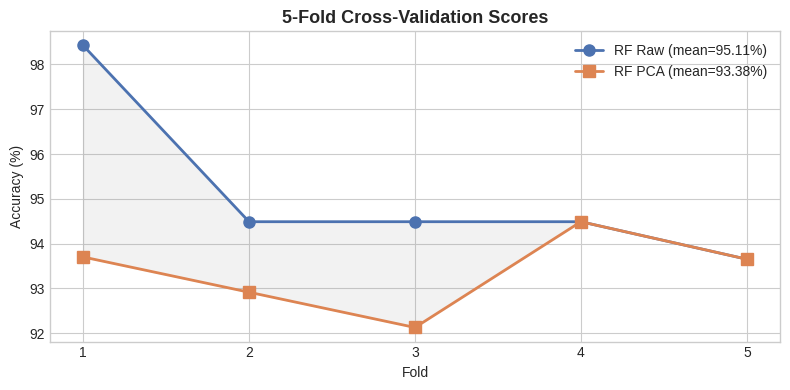

In [17]:
# ── Cross-validation scores comparison ──
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 6), cv_raw*100, 'o-', color='#4C72B0', linewidth=2, markersize=8,
        label=f'RF Raw (mean={cv_raw.mean()*100:.2f}%)')
ax.plot(range(1, 6), cv_pca*100, 's-', color='#DD8452', linewidth=2, markersize=8,
        label=f'RF PCA (mean={cv_pca.mean()*100:.2f}%)')
ax.fill_between(range(1, 6), cv_raw*100, cv_pca*100, alpha=0.1, color='gray')
ax.set_xticks(range(1, 6))
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy (%)')
ax.set_title('5-Fold Cross-Validation Scores', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
# ── Final summary ──
diff = (acc_pca - acc_raw) * 100
sign = '+' if diff >= 0 else ''

print('='*60)
print('  FINAL COMPARISON REPORT')
print('='*60)
print(f'  RF on Raw Features (18 dims):     {acc_raw*100:.2f}%')
print(f'  RF on PCA Features ({n_components} dims):     {acc_pca*100:.2f}%')
print(f'  Accuracy difference:              {sign}{diff:.2f}%')
print(f'  Dimensionality reduction:         {18} → {n_components} ({(1-n_components/18)*100:.0f}% fewer features)')
print()
if abs(diff) < 1.5:
    print('  ✅ PCA retains comparable accuracy with fewer features.')
    print('     This demonstrates the power of dimensionality reduction —')
    print('     similar performance at lower computational cost.')
elif diff > 0:
    print('  🎉 PCA actually improved accuracy!')
    print('     Removing noisy/correlated features helped the classifier.')
else:
    print('  ⚠️  PCA reduced accuracy slightly.')
    print('     The discarded variance contained class-discriminative info.')
print('='*60)

  FINAL COMPARISON REPORT
  RF on Raw Features (18 dims):     97.17%
  RF on PCA Features (10 dims):     94.34%
  Accuracy difference:              -2.83%
  Dimensionality reduction:         18 → 10 (44% fewer features)

  ⚠️  PCA reduced accuracy slightly.
     The discarded variance contained class-discriminative info.
